In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import h5py
import os
import tqdm
import scipy
from scipy import signal
from tqdm import tnrange
import seaborn as sns
from scipy.stats import norm,entropy,linregress
from scipy.optimize import minimize, curve_fit
from scipy.io import savemat
# import multiprocess as mp
# from multiprocess import Pool
from scipy.special import erf
import sys
import warnings
warnings.filterwarnings('ignore')

cmap = plt.rcParams['axes.prop_cycle'].by_key()['color']
modulename = 'multiprocess'

mpl.rcParams['svg.fonttype'] = 'none'
sns.set_context('poster', font_scale=1.1)

import odor_breathing_functions
import functions_beh

#path = os.getcwd() + '/Session/'
savepath = os.getcwd() + '/Figures/test/'
savepath_pdf = os.getcwd() + '/Figures/test/pdf/'
savepath_png = os.getcwd() + '/Figures/test/png/'
savepath_svg = os.getcwd() + '/Figures/test/svg/'

#dir_list = os.listdir(path)
#np_savepath = os.getcwd() + '/Other_outputs/MLE_arrays/'

#print(os.getcwd())


In [2]:

c_2 = plt.cm.get_cmap('RdPu')
cmap = plt.get_cmap("tab10")
cmap_2 = sns.color_palette("rocket", 7)
cmap_3 = sns.color_palette("mako", 7)
cmap_4 = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)(np.linspace(0, 0.75, 7))
cmap_5 = sns.color_palette("rocket_r", as_cmap=True)(np.linspace(0.1, 0.8, 7))
cmap_6 = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)(np.linspace(0, 0.8, 5))
cmap_7 = sns.color_palette("YlGn", 10)
cmap_8 = sns.color_palette("bone_r", 10)
cmap_9 = sns.color_palette("Accent", 12)
cmap_10 = sns.color_palette('bright',10)
cmap_11 = sns.color_palette('plasma',10)

greys = sns.color_palette("Greys", 10)
colors = plt.cm.get_cmap('BuGn')(np.linspace(0.4, 1, 7))
blue_palette = sns.dark_palette(cmap(0),n_colors=9, reverse=True)
orange_palette = sns.dark_palette(cmap(1),n_colors=9, reverse=True)
red_palette = sns.dark_palette(cmap(3),n_colors=9, reverse=True)

cmap_12 = sns.choose_dark_palette()
glom_palette = sns.cubehelix_palette(start=0, hue = .9, light = 0.8, dark=0.15, gamma=0.9, rot=-0.4, as_cmap=True)
glom_palette_2 = sns.cubehelix_palette(n_colors=18, start=0, hue = .9, light = 0.8, dark=0.15, gamma=0.9, rot=-0.4)#, as_cmap=True)
wistia_palette = sns.color_palette('Wistia', 10)
glom_p = glom_palette_2[::-1]

interactive(children=(IntSlider(value=179, description='h', max=359), IntSlider(value=49, description='s', max…

In [3]:
with h5py.File('./adaptation_data_HW1_50ms_struct_good.mat', 'r') as f:
    breath = f['imaging_struct/breath'][:]
    odor = f['imaging_struct/odor'][:]
    valve = f['imaging_struct/valve'][:]
    df_data = f['imaging_struct/df_data'][:]
print(breath.shape)

(2119200, 1)


231000
538000


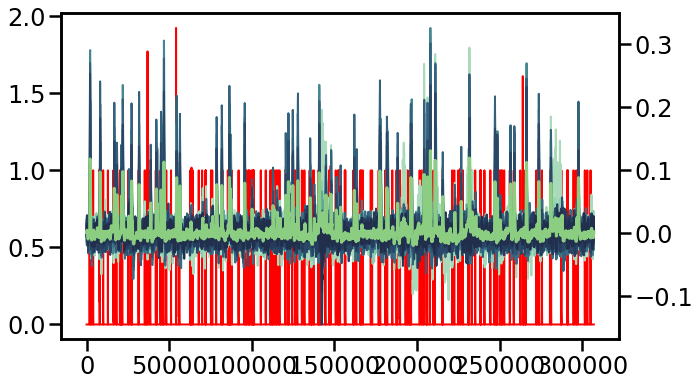

In [4]:
sniff = odor_breathing_functions.butter_lowpass_filter(breath.flatten(),10,1000,3)
begin = int(38.1*(10000)-(15)*(10000)) #27.5 35
end = int(38.8*(10000)+(15)*(10000)) #28 36

print(begin)
print(end)
interval = end-begin
samp_interval = 100

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(odor[begin:end], linewidth=2, color='r')
ax2 = ax1.twinx()

for i in range(df_data.shape[1]):

    ax2.plot(np.linspace(0,interval,int(interval/samp_interval)), 
            df_data[int(begin/samp_interval):int(end/samp_interval), i], 
            color=glom_palette_2[i], linewidth=2)

ax2.plot(np.linspace(0,interval,int(interval/samp_interval)), 
                     df_data.mean(1)[int(begin/samp_interval):int(end/samp_interval)],
                     color=cmap_7[4], linewidth=3)

In [7]:
odor_array = odor[begin:end]
sniff_array = sniff[begin:end]
gcamp_mult_glomeruli = df_data[int(begin/samp_interval):int(end/samp_interval), :]
glomeruli_mean = df_data.mean(1)[int(begin/samp_interval):int(end/samp_interval)]
gcamp_glomeruli = np.append([glomeruli_mean], gcamp_mult_glomeruli.T, axis=0).T

df_gcamp = pd.DataFrame(gcamp_glomeruli, columns=['glomeruli_mean'] + [f'glomerulus_{i}' for i in range(gcamp_mult_glomeruli.shape[1])])
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    df_gcamp.to_excel(writer, sheet_name="Fig_3B", index=False)

df_odor_breathing_rep_traces = pd.DataFrame({'Odor trace': odor_array.squeeze(), 'Sniff trace': sniff_array.squeeze()})
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    df_odor_breathing_rep_traces.to_excel(writer, sheet_name="Fig_3B_odor", index=False)


ModuleNotFoundError: No module named 'openpyxl'

dict_keys(['__header__', '__version__', '__globals__', 'HW1_mid', 'HW1_onset', 'HW1_peak', 'HW4_mid', 'HW4_onset', 'HW4_peak', 'Sphinx_mid', 'Sphinx_onset', 'Sphinx_peak'])
(18, 15)
dict_keys(['__header__', '__version__', '__globals__', 'HW1_mid', 'HW1_onset', 'HW1_peak', 'HW4_mid', 'HW4_onset', 'HW4_peak', 'Sphinx_mid', 'Sphinx_onset', 'Sphinx_peak'])
(53, 15)
dict_keys(['__header__', '__version__', '__globals__', 'HW1_mid', 'HW1_onset', 'HW1_peak', 'HW4_mid', 'HW4_onset', 'HW4_peak', 'Sphinx_mid', 'Sphinx_onset', 'Sphinx_peak'])
(35, 15)


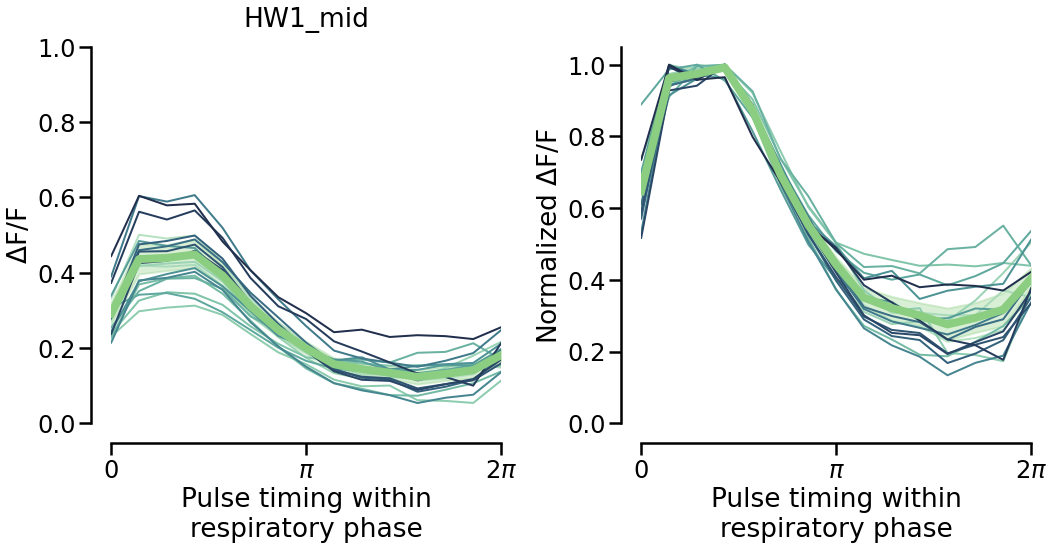

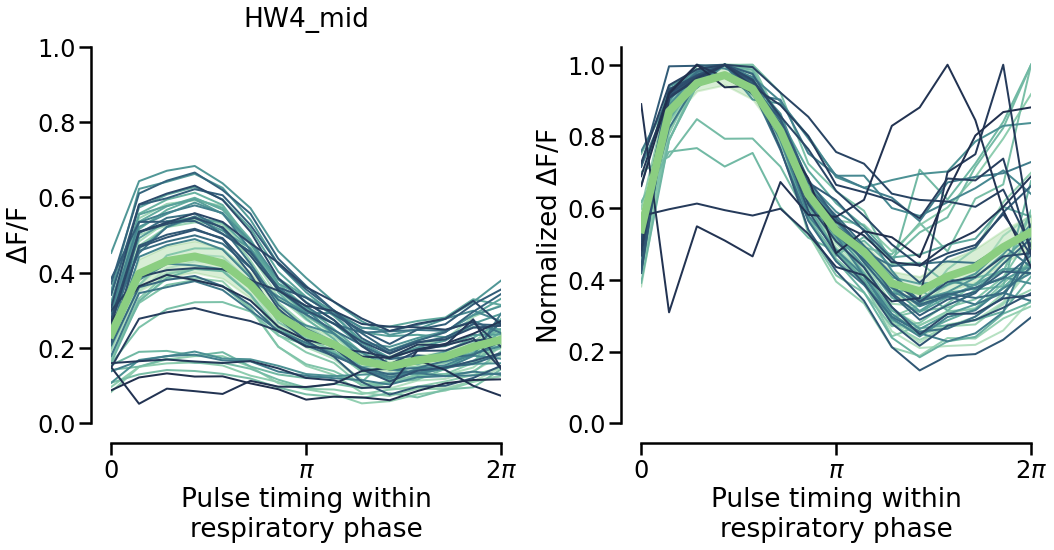

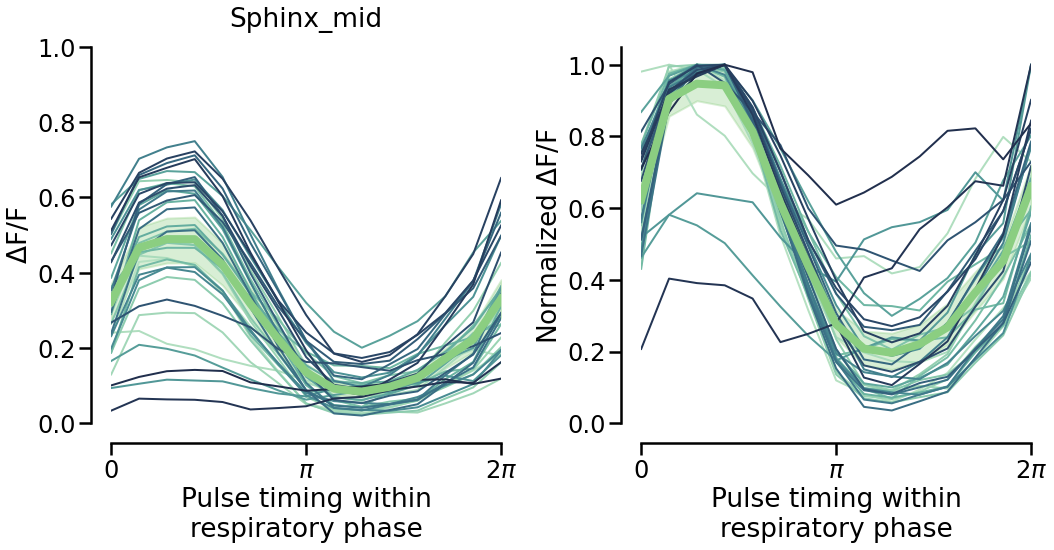

In [5]:
matlab_filepath = os.getcwd() + '/Kernel_workspace.mat'

def phase_transform(x):
    return (0+((x-1)*(2*np.pi-0)/(14)))

def calcium_kernel(matlab_filepath, table_name):
    file = scipy.io.loadmat(matlab_filepath)
    print(file.keys())
    glom_matrix = file[table_name]
    print(glom_matrix.shape)
    kernel_mean = glom_matrix.mean(0)
    kernel_std = glom_matrix.std(0)  
    norm_glom_matrix = np.ones_like(glom_matrix)
    colx = [i for i in range(1,16)]  

    for i in range(glom_matrix.shape[0]):
        norm_glom_matrix[i,:] = glom_matrix[i,:]/glom_matrix[i,:].max()

    df_g = pd.DataFrame(glom_matrix, columns=colx)
    df_g.insert(0, 'Glom', np.arange(0,len(glom_matrix)))
    df_g2 = df_g.melt(id_vars='Glom', var_name='Bin', value_name='dF_F')
    df_g2['Breathing phase'] = df_g2['Bin'].apply(phase_transform)
    df_g2['Animal'] = table_name

  
    df_gn = pd.DataFrame(norm_glom_matrix, columns=colx)
    df_gn.insert(0, 'Glom', np.arange(0,len(norm_glom_matrix)))
    df_gn2 = df_gn.melt(id_vars='Glom', var_name='Bin', value_name='dF_F')
    df_gn2['Breathing phase'] = df_gn2['Bin'].apply(phase_transform)
    df_gn2['Animal'] = table_name
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,8))

    sns.lineplot(x=df_g2['Breathing phase'], y=df_g2['dF_F'], hue=df_g2['Glom'], legend=False, 
             palette=glom_palette, linewidth=2, clip_on=True, ax=ax1)
    
    sns.lineplot(x=df_g2['Breathing phase'], y=df_g2['dF_F'], errorbar=('ci'),
                 color=cmap_7[4], linewidth=8, ax=ax1, err_kws={'alpha':0.33}) #wistia_palette[1]
    
    ax1.set_xticks([0,np.pi,2*np.pi])
    ax1.set_xticklabels(['0','$\pi$','$2\pi$'])
    ax1.set_xlim(0,2*np.pi)
    ax1.set_ylim(0,1)
    ax1.set_ylabel('$\Delta $F/F',)
    ax1.set_xlabel('Pulse timing within\nrespiratory phase')
    ax1.set_title(table_name, pad=20)

    sns.despine(offset=20)

    sns.lineplot(x=df_gn2['Breathing phase'], y=df_gn2['dF_F'], hue=df_g2['Glom'], legend=False, 
             palette=glom_palette, linewidth=2, clip_on=True, ax=ax2) #sns.color_palette("mako", as_cmap=True)
    
    sns.lineplot(x=df_gn2['Breathing phase'], y=df_gn2['dF_F'], errorbar=('ci'),
                 color=cmap_7[4], linewidth=8, ax=ax2, err_kws={'alpha':0.33})

    ax2.set_xticks([0,np.pi,2*np.pi])
    ax2.set_xticklabels(['0','$\pi$','$2\pi$'])
    ax2.set_xlim(0,2*np.pi)
    ax2.set_ylim(0,1.05)
    ax2.set_ylabel('Normalized $\Delta $F/F')
    ax2.set_xlabel('Pulse timing within\nrespiratory phase')
    sns.despine(offset=20)
    plt.tight_layout(pad=2)

    return fig, df_g2, df_gn2

fig_hw1, table_hw1, table_hw1_norm =  calcium_kernel(matlab_filepath, 'HW1_mid')
fig_hw4, table_hw4, table_hw4_norm =  calcium_kernel(matlab_filepath, 'HW4_mid')
fig_sphinx, table_sphinx, table_sphinx_norm =  calcium_kernel(matlab_filepath, 'Sphinx_mid')

# fig_hw1.savefig(savepath_svg + 'all_glomerular_weights_hw1_peak.svg', transparent=True, format='svg', bbox_inches='tight')
# fig_hw1.savefig(savepath_png + 'all_glomerular_weights_hw1_peak.png', transparent=True, format='png', bbox_inches='tight')
# fig_hw1.savefig(savepath_pdf + 'all_glomerular_weights_hw1_peak.pdf', transparent=True, format='pdf', bbox_inches='tight')

# fig_hw4.savefig(savepath_svg + 'all_glomerular_weights_hw4_peak.svg', transparent=True, format='svg', bbox_inches='tight')
# fig_hw4.savefig(savepath_png + 'all_glomerular_weights_hw4_peak.png', transparent=True, format='png', bbox_inches='tight')
# fig_hw4.savefig(savepath_pdf + 'all_glomerular_weights_hw4_peak.pdf', transparent=True, format='pdf', bbox_inches='tight')

# fig_sphinx.savefig(savepath_svg + 'all_glomerular_weights_sphinx_peak.svg', transparent=True, format='svg', bbox_inches='tight')
# fig_sphinx.savefig(savepath_png + 'all_glomerular_weights_sphinx_peak.png', transparent=True, format='png', bbox_inches='tight')
# fig_sphinx.savefig(savepath_pdf + 'all_glomerular_weights_sphinx_peak.pdf', transparent=True, format='pdf', bbox_inches='tight')



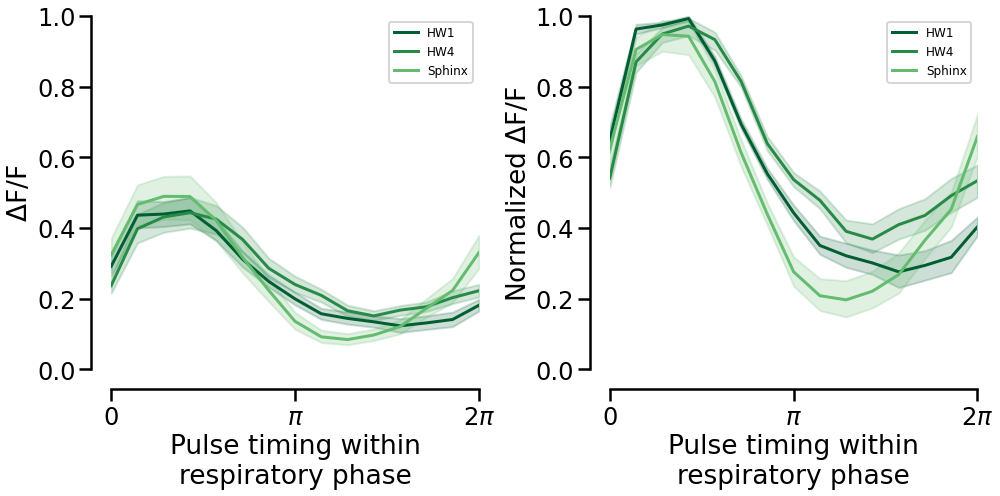

In [6]:
calcium_data_combined = pd.concat([table_hw1, table_hw4, table_sphinx], axis=0).reset_index(drop=True)
calcium_normalized = pd.concat([table_hw1_norm, table_hw4_norm, table_sphinx_norm], axis=0).reset_index(drop=True)

fig_avg, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))

plot1 = sns.lineplot(x=calcium_data_combined['Breathing phase'], 
             y=calcium_data_combined['dF_F'], 
             hue=calcium_data_combined['Animal'],
             palette=cmap_7[-1::-2], ax=ax1)

handles, labels = plot1.get_legend_handles_labels()

handlex = [h for h, l in zip(handles, labels) if 'Animal' in l]
labelx = ['HW1', 'HW4', 'Sphinx']

plot1.legend(handles=handles, labels=labelx, fontsize='large')
plot1.set_xticks([0,np.pi,2*np.pi])
plot1.set_xticklabels(['0','$\pi$','$2\pi$'])
plot1.set_xlim(0,2*np.pi)
plot1.set_ylim(0,1)
plot1.set_ylabel('$\Delta $F/F',)
plot1.set_xlabel('Pulse timing within\nrespiratory phase')

sns.despine(offset=20)


plot2 = sns.lineplot(x=calcium_normalized['Breathing phase'], 
             y=calcium_normalized['dF_F'], 
             hue=calcium_normalized['Animal'],
             palette=cmap_7[-1::-2], ax=ax2, legend=False)

plot2.legend(handles=handles, labels=labelx, fontsize='large')

plot2.set_xticks([0,np.pi,2*np.pi])
plot2.set_xticklabels(['0','$\pi$','$2\pi$'])
plot2.set_xlim(0,2*np.pi)
plot2.set_ylim(0,1)
plot2.set_ylabel('Normalized $\Delta $F/F',)
plot2.set_xlabel('Pulse timing within\nrespiratory phase')

# fig_avg.savefig(savepath_svg + 'avg_glomerular_weights_all_animals_peak.svg', transparent=True, format='svg', bbox_inches='tight')
# fig_avg.savefig(savepath_png + 'avg_glomerular_weights_all_animals_peak.png', transparent=True, format='png', bbox_inches='tight')
# fig_avg.savefig(savepath_pdf + 'avg_glomerular_weights_all_animals_peak.pdf', transparent=True, format='pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()

In [24]:
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    calcium_data_combined.to_excel(writer, sheet_name="Supp_Fig_4", index=False)

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    calcium_normalized.to_excel(writer, sheet_name="Supp_Fig_4B", index=False)

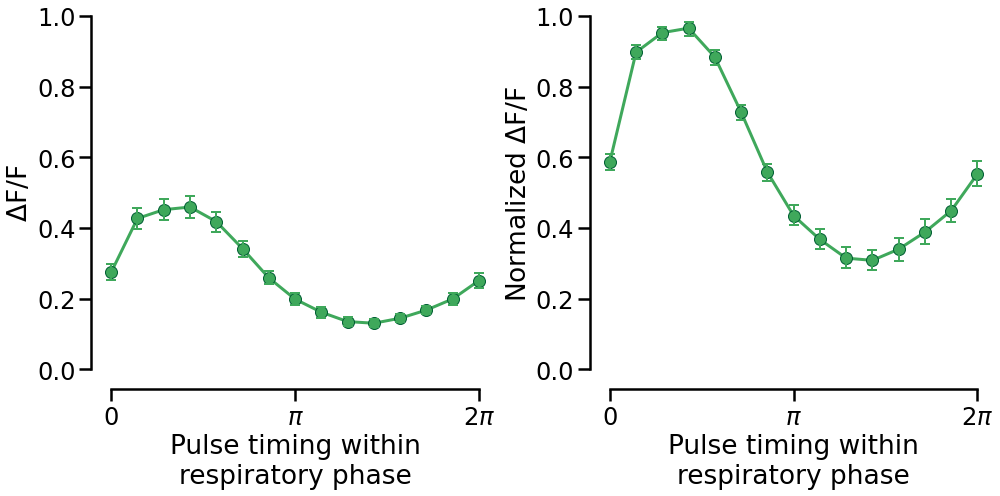

In [7]:
fig_kernel, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))

plot1 = sns.lineplot(x=calcium_data_combined['Breathing phase'], 
             y=calcium_data_combined['dF_F'], ax=ax1, marker="o", dashes=False, markersize=12, 
             err_style='bars', legend=False, err_kws={'capsize':5,'capthick':2,'elinewidth':2,'clip_on':False},
             color=cmap_7[6], markeredgewidth=1, markerfacecolor=cmap_7[6],markeredgecolor=cmap_7[9], clip_on=False)

plot2 = sns.lineplot(x=calcium_normalized['Breathing phase'], 
             y=calcium_normalized['dF_F'], ax=ax2, marker="o", dashes=False, markersize=12, 
             err_style='bars', errorbar='ci', legend=False, err_kws={'capsize':5,'capthick':2,'elinewidth':2, 'clip_on':False},
             color=cmap_7[6], markeredgewidth=1, markerfacecolor=cmap_7[6],markeredgecolor=cmap_7[9], clip_on=False)

plot1.set_xticks([0,np.pi,2*np.pi])
plot1.set_xticklabels(['0','$\pi$','$2\pi$'])
plot1.set_xlim(0,2*np.pi)
plot1.set_ylim(0,1)
plot1.set_ylabel('$\Delta $F/F',)
plot1.set_xlabel('Pulse timing within\nrespiratory phase')
sns.despine(offset=20)

plot2.set_xticks([0,np.pi,2*np.pi])
plot2.set_xticklabels(['0','$\pi$','$2\pi$'])
plot2.set_xlim(0,2*np.pi)
plot2.set_ylim(0,1)
plot2.set_ylabel('Normalized $\Delta $F/F' ,)
plot2.set_xlabel('Pulse timing within\nrespiratory phase')

plt.tight_layout()

# fig_kernel.savefig(savepath_svg + 'calcium_kernel_average_peak.svg', transparent=True, format='svg', bbox_inches='tight')
# fig_kernel.savefig(savepath_png + 'calcium_kernel_average_peak.png', transparent=True, format='png', bbox_inches='tight')
# fig_kernel.savefig(savepath_pdf + 'calcium_kernel_average_peak.pdf', transparent=True, format='pdf', bbox_inches='tight')

plt.show()

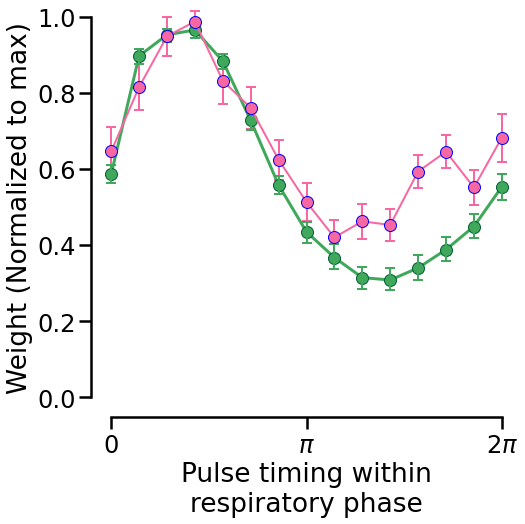

In [12]:
log_reg_sniffing_mean = np.load("new_log_reg_mean_array.npy")
log_reg_sniffing_std = np.load("new_log_reg_std_array.npy")

plt.figure(figsize=(7,7))

plt.errorbar(calcium_normalized['Breathing phase'].unique(),log_reg_sniffing_mean,log_reg_sniffing_std,ls='-', marker = 'o', markeredgecolor = 'b', linewidth=2, color = c_2(0.5), clip_on=False, capsize=5, capthick=2, elinewidth=2)
#plt.fill_between(calcium_normalized['Breathing phase'].unique(),log_reg_sniffing_mean-log_reg_sniffing_std, log_reg_sniffing_mean+log_reg_sniffing_std, linewidth=2, color = c_2(0.5), alpha=0.3, clip_on=False)
sns.lineplot(x=calcium_normalized['Breathing phase'], y=calcium_normalized['dF_F'], marker="o", dashes=False, markersize=12, err_style='bars', errorbar='ci', legend=False, err_kws={'capsize':5,'capthick':2,'elinewidth':2, 'clip_on':False},
             color=cmap_7[6], markeredgewidth=1, markerfacecolor=cmap_7[6],markeredgecolor=cmap_7[9], clip_on=False)


#plt.xticks([0,np.pi,2*np.pi], ['0','$\pi$','$2\pi$'])
plt.xlabel('Pulse timing within\nrespiratory phase')
plt.ylabel('Weight (Normalized to max)')
plt.xlim(0,2*np.pi)
plt.ylim(0,1)
ax = plt.gca()
ax.set_xticks([0,np.pi,2*np.pi])
ax.set_xticklabels(['0','$\pi$','$2\pi$'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
sns.despine(right=True, top=True, offset=20)

plt.savefig(savepath_svg + 'figure3c.svg', transparent=True, format='svg', bbox_inches='tight')
plt.savefig(savepath_png + 'figure3c.png', transparent=True, format='png', bbox_inches='tight')
plt.savefig(savepath_pdf + 'figure3c.pdf', transparent=True, format='pdf', bbox_inches='tight')
plt.show()

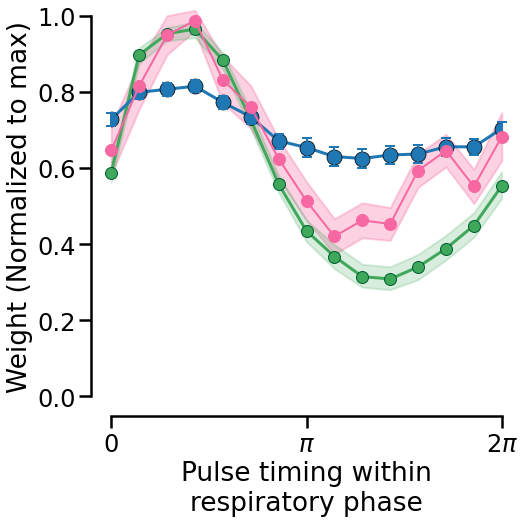

In [ ]:

phase_codes_df = pd.read_csv('phase_normalized_to_max.csv')

plt.figure(figsize=(7,7))

plt.errorbar(calcium_normalized['Breathing phase'].unique(),log_reg_sniffing_mean,ls='-', marker = 'o', linewidth=2, color = c_2(0.5), clip_on=False)
plt.fill_between(calcium_normalized['Breathing phase'].unique(),log_reg_sniffing_mean-log_reg_sniffing_std, log_reg_sniffing_mean+log_reg_sniffing_std, linewidth=2, color = c_2(0.5), alpha=0.3, clip_on=False)
sns.lineplot(x=calcium_normalized['Breathing phase'], y=calcium_normalized['dF_F'], marker="o", dashes=False, markersize=12, err_style='band', errorbar='ci', legend=False, #err_kws={'capsize':5,'capthick':2,'elinewidth':2, 'clip_on':False}
             color=cmap_7[6], markeredgewidth=1, markerfacecolor=cmap_7[6],markeredgecolor=cmap_7[9], clip_on=False)
sns.lineplot(data=phase_codes_df, x='phase_rad', y='mean_norm', err_style='bars', errorbar=('ci',95), marker='o', markersize=15, markeredgecolor='k', 
             legend=False, err_kws={'capsize':5,'capthick':2,'elinewidth':2, 'clip_on':False})

#plt.xticks([0,np.pi,2*np.pi], ['0','$\pi$','$2\pi$'])
plt.xlabel('Pulse timing within\nrespiratory phase')
plt.ylabel('Weight (Normalized to max)')
plt.xlim(0,2*np.pi)
plt.ylim(0,1)
ax = plt.gca()
ax.set_xticks([0,np.pi,2*np.pi])
ax.set_xticklabels(['0','$\pi$','$2\pi$'])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
sns.despine(right=True, top=True, offset=20)

# plt.savefig(savepath_svg + 'apcx_codes_beh_weights_and_calcium_newver.svg', transparent=True, format='svg', bbox_inches='tight')
# plt.savefig(savepath_png + 'apcx_codes_beh_weights_and_calcium_newver.png', transparent=True, format='png', bbox_inches='tight')
# plt.savefig(savepath_pdf + 'apcx_codes_beh_weights_and_calcium_newver.pdf', transparent=True, format='pdf', bbox_inches='tight')
# plt.show()


In [19]:
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    phase_codes_df.to_excel(writer, sheet_name="Figure_5G_codes", index=False)

In [14]:
def  kernel_mean_confidence_interval(x):
    mean =  np.mean(x)
    sem = scipy.stats.sem(x)
    conf_interval = sem * scipy.stats.t.ppf((1+0.95)/2.,len(x)-1)
    return mean, mean-conf_interval, mean + conf_interval

calcium_summary_df = calcium_normalized.groupby(['Bin', 'Breathing phase'])['dF_F'].agg(mean='mean',
                                                                   ci_lower=lambda x:kernel_mean_confidence_interval(x)[1],
                                                                   ci_upper=lambda x:kernel_mean_confidence_interval(x)[2]).reset_index()

calcium_summary_df['behavioral_weights_mean'] = log_reg_sniffing_mean
calcium_summary_df['behavioral_weights_std'] = log_reg_sniffing_std
calcium_summary_df

,Bin,Breathing phase,mean,ci_lower,ci_upper,behavioral_weights_mean,behavioral_weights_std
0,1,0.000000,0.586577,0.561703,0.611452,0.646098,0.064139
1,2,0.448799,0.897176,0.876489,0.917862,0.815376,0.061471
2,3,0.897598,0.952588,0.933874,0.971302,0.948809,0.051299
3,4,1.346397,0.965324,0.944502,0.986145,0.987482,0.026849
4,5,1.795196,0.883417,0.862106,0.904729,0.831782,0.060630
5,6,2.243995,0.727575,0.704561,0.750589,0.760511,0.056111
6,7,2.692794,0.557841,0.534885,0.580797,0.624452,0.052092
7,8,3.141593,0.434660,0.406359,0.462961,0.513100,0.050653
8,9,3.590392,0.367383,0.336119,0.398647,0.420151,0.046418
9,10,4.039191,0.314575,0.284591,0.344559,0.462422,0.045995


this is the two-sided p-value: 1.413253501067127e-07 this is the pearson coef value: 0.9429299925187268


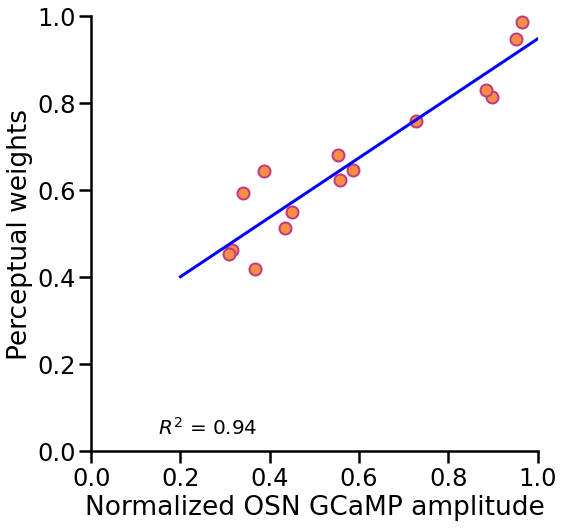

In [17]:
xsk = calcium_summary_df['mean']
ysk = calcium_summary_df['behavioral_weights_mean']
slope, intercept, r_value, p_value, std_err = linregress(xsk,ysk)
xid = np.linspace(-1,2,20)
yid = np.linspace(-1,2,20)
new_x = np.linspace(0.2,1,100)
new_y = new_x*slope+intercept

plt.figure(figsize=(8,8))
plt.scatter(calcium_summary_df['mean'],calcium_summary_df['behavioral_weights_mean'], color=cmap_11[7], edgecolors=cmap_11[4], clip_on=False)
#plt.plot(xid,yid,'k')
plt.plot(new_x, new_y, 'b')
#plt.plot(np.linspace(0,1,20),np.linspace(0,1,20)*slope+intercept,'k')

plt.xlabel('Normalized OSN GCaMP amplitude')
plt.ylabel('Perceptual weights')
plt.xlim(0,1)
plt.ylim(0,1)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#plt.savefig('figures/ca_vs_weights.svg')
ax.text(0.15, 0.03, '$R^2$ = %.2f'%r_value,
        verticalalignment='bottom', horizontalalignment='left',
        transform=ax.transAxes,
        color='k', fontsize=20)

print('this is the two-sided p-value:', p_value, 'this is the pearson coef value:', r_value)

rho = np.corrcoef(calcium_summary_df['mean'],calcium_summary_df['behavioral_weights_mean'])
plt.savefig(savepath_svg + 'figure3d.svg', transparent=True, format='svg', bbox_inches='tight')
plt.savefig(savepath_png + 'figure3d.png', transparent=True, format='png', bbox_inches='tight')
plt.savefig(savepath_pdf + 'figure3d.pdf', transparent=True, format='pdf', bbox_inches='tight')

plt.show()

In [66]:
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    calcium_summary_df.to_excel(writer, sheet_name="Fig_3_CD", index=False)